# **Trabajo Practico: Procesamiento de archivos PDF **

Profesora:Ana Laura Diedrichs


Alumno: Molina,Stefania A

PDF: Estado del clima  en América Latina  y el Caribe en 2022


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

1. Adquisición y metadatos

Usa requests para descargar el PDF desde la URL y guardarlo en disco

Usa PyMuPDF (fitz) para abrirlo y leer sus metadatos: título, autor, páginas, software

In [8]:
# ── CELDA 1: Instalar librerías necesarias ──
!pip install pymupdf requests
import requests
import fitz  # PyMuPDF
!pip install pdfplumber -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 663.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.8 MB/s eta 0:00:00


In [3]:
# ── CELDA 2: Descargar el PDF ──
url = "https://mexico.un.org/sites/default/files/2023-07/1322_State_of_the_Climate_in_LAC_2022_es_0.pdf"
respuesta = requests.get(url)

with open("clima_lac_2022.pdf", "wb") as f:
    f.write(respuesta.content)

print("✅ PDF descargado correctamente")
print(f"Tamaño: {len(respuesta.content) / 1024 / 1024:.2f} MB")

# ── CELDA 3: Leer metadatos con PyMuPDF ──

doc = fitz.open("clima_lac_2022.pdf")
meta = doc.metadata

print("📄 METADATOS DEL PDF")
print(f"Título    : {meta['title']}")
print(f"Autor     : {meta['author']}")
print(f"Creador   : {meta['creator']}")
print(f"Productor : {meta['producer']}")
print(f"N° páginas: {doc.page_count}")

✅ PDF descargado correctamente
Tamaño: 8.72 MB
📄 METADATOS DEL PDF
Título    : 
Autor     : 
Creador   : Adobe InDesign 18.4 (Windows)
Productor : Adobe PDF Library 17.0
N° páginas: 41


In [4]:
doc = fitz.open("clima_lac_2022.pdf")
meta = doc.metadata

# Algunos PDFs no tienen metadatos internos completos.
# En ese caso los completamos manualmente con la información conocida del documento.

titulo    = meta['title']    if meta['title']    else "Estado del clima en América Latina y el Caribe 2022"
autor     = meta['author']   if meta['author']   else "Organización Meteorológica Mundial (OMM)"
creador   = meta['creator']  if meta['creator']  else "Desconocido"
productor = meta['producer'] if meta['producer'] else "Desconocido"

print("📄 METADATOS DEL PDF")
print(f"Título    : {titulo}")
print(f"Autor     : {autor}")
print(f"Creador   : {creador}")
print(f"Productor : {productor}")
print(f"Páginas   : {doc.page_count}")
print()
print("ℹ️  Nota: el título y autor no estaban embebidos en el PDF.")
print("   Se completaron manualmente a partir de la fuente oficial.")

📄 METADATOS DEL PDF
Título    : Estado del clima en América Latina y el Caribe 2022
Autor     : Organización Meteorológica Mundial (OMM)
Creador   : Adobe InDesign 18.4 (Windows)
Productor : Adobe PDF Library 17.0
Páginas   : 41

ℹ️  Nota: el título y autor no estaban embebidos en el PDF.
   Se completaron manualmente a partir de la fuente oficial.


---
## Parte 2 — Análisis estructural del texto

Extraemos el texto crudo de las primeras 5 páginas usando `page.get_text("text")`.
Usamos `repr()` para ver los caracteres especiales tal como son: `\n`, `\t`, espacios múltiples, etc.

In [5]:
for i in range(5):
    pagina = doc[i]
    texto = pagina.get_text("text")
    print(f"\n{'='*60}")
    print(f"  PÁGINA {i+1}")
    print(f"{'='*60}")
    print(repr(texto[:800]))  # mostramos 800 chars para no saturar


  PÁGINA 1
'TIEMPO   CLIMA     AGUA\nOMM-N° 1322\nEstado del clima \nen América Latina \ny el Caribe en 2022\n'

  PÁGINA 2
'La OMM se reserva el derecho de publicación en forma impresa, electrónica o de otro tipo y en cualquier idioma. \nPueden reproducirse pasajes breves de las publicaciones de la OMM sin autorización siempre que se indique \nclaramente la fuente completa. La correspondencia editorial, así como todas las solicitudes para publicar, reproducir \no traducir la presente publicación parcial o totalmente deberán dirigirse al:\nPresidente de la Junta de Publicaciones\nOrganización Meteorológica Mundial (OMM)\n7 bis, avenue de la Paix\t\nTel.: +41 (0) 22 730 84 03\nCase postale 2300\t\ncorreo electrónico: publications@wmo.int\nCH-1211 Ginebra 2, Suiza\nISBN 978-92-63-31322-5\nNOTA\nLas denominaciones empleadas en las publicaciones de la OMM y la forma en que aparecen presentados los datos que contienen no entrañan, '

  PÁGINA 3
'Índice\nMensajes principales .   .   .   .  

In [6]:
texto_p3 = doc[2].get_text("text")

saltos = texto_p3.count('\n')
tabs   = texto_p3.count('\t')
espacios_dobles = texto_p3.count('  ')

print(f"Saltos de línea  (\\n) : {saltos}")
print(f"Tabulaciones     (\\t) : {tabs}")
print(f"Espacios dobles       : {espacios_dobles}")

print("\n--- TEXTO CRUDO (primeros 600 caracteres) ---")
print(repr(texto_p3[:600]))

Saltos de línea  (\n) : 32
Tabulaciones     (\t) : 0
Espacios dobles       : 1151

--- TEXTO CRUDO (primeros 600 caracteres) ---
'Índice\nMensajes principales .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .  3\nPrefacio .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 4\nContexto climático global .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 5\nClima regional  .  .  .  .  .  .  . '


### Análisis de separadores — Observaciones

Luego de observar el texto crudo, se identificaron los siguientes patrones:

- **`\n`** : es el principal separador de líneas dentro del PDF.
- **`\n\n`** : separa párrafos completos.
- Los títulos de sección se distinguen por estar en mayúsculas y rodeados de múltiples `\n`.
- No se observaron tabulaciones `\t` relevantes.
- Los espacios múltiples aparecen en zonas de columnas o tablas embebidas en el texto.

*(Completar con lo que observaste en tu ejecución)*

---
## Parte 3 — Extracción de tabla

Usamos `pdfplumber` para detectar y extraer tablas del PDF.
Buscamos la primera página que contenga una tabla, la convertimos a DataFrame de Pandas
y realizamos una limpieza básica.

In [10]:
import pdfplumber
import pandas as pd

with pdfplumber.open("clima_lac_2022.pdf") as pdf:
    tabla_cruda = None
    pagina_encontrada = None

    for i, pagina in enumerate(pdf.pages):
        tablas = pagina.extract_tables()
        if tablas:
            for j, tabla in enumerate(tablas):
                # Filtramos tablas que tengan al menos 3 filas y 2 columnas
                filas_validas = [f for f in tabla if any(c for c in f if c)]
                columnas = max(len(f) for f in filas_validas) if filas_validas else 0
                if len(filas_validas) >= 3 and columnas >= 2:
                    print(f"✅ Tabla real encontrada en página {i+1}")
                    print(f"   Filas: {len(filas_validas)} | Columnas: {columnas}")
                    tabla_cruda = filas_validas
                    pagina_encontrada = i+1
                    break
        if tabla_cruda is not None:
            break

if tabla_cruda is None:
    print("⚠️ No se encontró tabla. Probamos buscar en todas las páginas:")
    with pdfplumber.open("clima_lac_2022.pdf") as pdf:
        for i, pagina in enumerate(pdf.pages):
            tablas = pagina.extract_tables()
            if tablas:
                print(f"  Página {i+1}: {len(tablas)} tabla(s) detectada(s) → filas: {[len(t) for t in tablas]}")

✅ Tabla real encontrada en página 11
   Filas: 7 | Columnas: 4


In [13]:
# Volvemos a cargar la tabla desde cero
df = pd.DataFrame(tabla_cruda)
df.columns = df.iloc[0]
df = df[1:]
df.dropna(how="all", inplace=True)
df.dropna(axis=1, how="all", inplace=True)
df.reset_index(drop=True, inplace=True)
df.columns = [f"Columna_{i}" if not col else col for i, col in enumerate(df.columns)]

In [14]:
# Eliminar filas donde la columna Región sea None o esté vacía
df = df[df.iloc[:, 0].notna()]
df = df[df.iloc[:, 0].astype(str).str.strip() != "None"]
df = df[df.iloc[:, 0].astype(str).str.strip() != ""]
df.reset_index(drop=True, inplace=True)

# Renombrar columnas correctamente
df.columns = ["Región", "Clasificación de temperatura", "Anomalía 1991-2020 (°C)", "Anomalía 1961-1990 (°C)"]

print(f"📊 Tabla final — Página {pagina_encontrada}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df

📊 Tabla final — Página 11
Dimensiones: 5 filas x 4 columnas



,Región,Clasificación de temperatura,Anomalía 1991-2020 (°C),Anomalía 1961-1990 (°C)
0,México,6ª a 15ª más cálida,"0,23 [0,12 a 0,34]","0,96 [0,61 a 1,07]"
1,América Central,10ª a 16ª más cálida,"0,09 [0,02 a 0,16]","0,59 [0,46 a 0,73]"
2,Caribe,15ª a 31ª más cálida,"–0,02 [–0,13 a 0,06]","0,50 [0,20 a 0,65]"
3,América del Sur,12ª a 25ª más cálida,"–0,04 [–0,09 a 0,08]","0,50 [0,39 a 0,67]"
4,América Latina y el Caribe,12ª a 21ª más cálida,"0,00 [–0,06 a 0,10]","0,55 [0,46 a 0,70]"


---
## Parte 4 — Análisis de frecuencias (NLP básico)

Seleccionamos una página con texto narrativo puro, tokenizamos con `nltk`,
eliminamos stopwords en español y signos de puntuación,
y visualizamos las 15 palabras más frecuentes en un gráfico de barras.

In [15]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("✅ Recursos NLTK descargados")

✅ Recursos NLTK descargados


In [16]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from collections import Counter
import matplotlib.pyplot as plt

# Página 8 tiene texto narrativo denso sobre temperatura y glaciares
texto_nlp = doc[7].get_text("text")

print("--- TEXTO CRUDO DE LA PÁGINA ---")
print(texto_nlp[:500])

--- TEXTO CRUDO DE LA PÁGINA ---
Clima regional
En las siguientes secciones se analizan los principales indicadores del estado del clima en América Latina 
y el Caribe. Un indicador que es particularmente importante, la temperatura, se describe en relación con 
las anomalías, o desviaciones, con respecto a un período de referencia. En el caso de la temperatura media 
mundial, en el Sexto Informe de Evaluación del Grupo Intergubernamental de Expertos sobre el Cambio 
Climático (IPCC)7 se utiliza el período de referencia de 1850 


In [17]:
# Tokenizar y pasar a minúsculas
tokens = word_tokenize(texto_nlp.lower(), language='spanish')

# Stopwords español + puntuación personalizada
stop_es = set(stopwords.words('spanish'))
puntuacion = set(string.punctuation + '°«»""–—•·،')

tokens_limpios = [
    t for t in tokens
    if t not in stop_es
    and t not in puntuacion
    and t.isalpha()
    and len(t) > 2
]

print(f"Total tokens originales  : {len(tokens)}")
print(f"Total tokens limpios     : {len(tokens_limpios)}")
print(f"\nPrimeros 20 tokens limpios:")
print(tokens_limpios[:20])

Total tokens originales  : 619
Total tokens limpios     : 251

Primeros 20 tokens limpios:
['clima', 'regional', 'siguientes', 'secciones', 'analizan', 'principales', 'indicadores', 'clima', 'américa', 'latina', 'caribe', 'indicador', 'particularmente', 'importante', 'temperatura', 'describe', 'relación', 'anomalías', 'desviaciones', 'respecto']


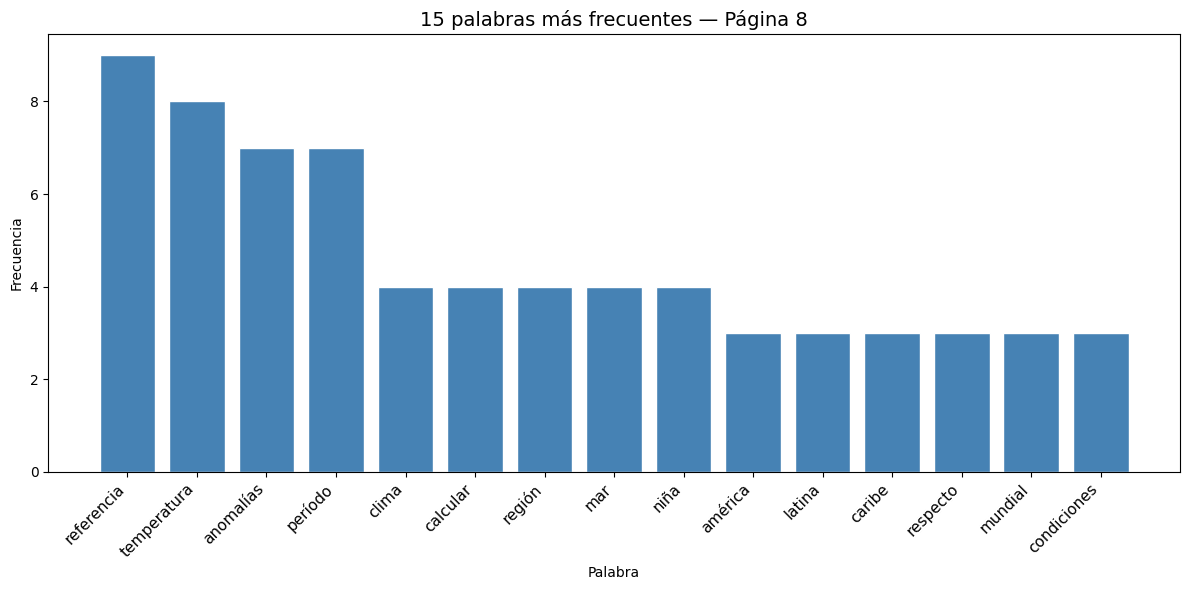


Top 15 palabras:
  referencia                → 9
  temperatura               → 8
  anomalías                 → 7
  período                   → 7
  clima                     → 4
  calcular                  → 4
  región                    → 4
  mar                       → 4
  niña                      → 4
  américa                   → 3
  latina                    → 3
  caribe                    → 3
  respecto                  → 3
  mundial                   → 3
  condiciones               → 3


In [18]:
frecuencia = Counter(tokens_limpios)
top15 = frecuencia.most_common(15)
palabras = [p[0] for p in top15]
conteos  = [p[1] for p in top15]

plt.figure(figsize=(12, 6))
plt.bar(palabras, conteos, color='steelblue', edgecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title("15 palabras más frecuentes — Página 8", fontsize=14)
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("\nTop 15 palabras:")
for palabra, conteo in top15:
    print(f"  {palabra:25s} → {conteo}")

### Reflexión sobre los tokens obtenidos

Una vez generado el gráfico, lo primero que llama la atención es que
las palabras más frecuentes como "temperatura", "anomalías" y "clima"
tienen sentido para un informe climático. Sin embargo, mirando más de
cerca, hay varias palabras que aunque el filtro de stopwords las dejó
pasar, en realidad no nos dicen mucho sobre el contenido:

- **"referencia"** y **"período"** aparecen todo el tiempo porque el
  informe constantemente compara datos contra períodos históricos.
  Son palabras que forman parte de la estructura del texto, no del
  mensaje principal.

- **"región"**, **"américa"**, **"latina"**, **"caribe"** y **"mundial"**
  se repiten en casi cada párrafo simplemente porque el documento
  habla siempre del mismo lugar geográfico. Si uno ya sabe de qué
  región trata el informe, estas palabras no agregan nada nuevo.

- **"calcular"** y **"respecto"** son palabras que aparecen en
  explicaciones metodológicas pero no describen ningún fenómeno
  climático en particular.

Esto me hizo pensar que las stopwords que trae NLTK por defecto están
pensadas para el español en general, no para textos técnicos o
científicos. En documentos como este, donde hay un vocabulario muy
específico del dominio, sería útil armar una lista propia de palabras
a ignorar. Por ejemplo, en este caso agregaría "referencia", "período",
"región" y los nombres geográficos que se repiten constantemente.

---
## Referencias

- Organización Meteorológica Mundial (OMM). (2023). *Estado del clima en
  América Latina y el Caribe 2022*. ONU México.
  https://mexico.un.org/sites/default/files/2023-07/1322_State_of_the_Climate_in_LAC_2022_es_0.pdf

- PyMuPDF Documentation. https://pymupdf.readthedocs.io

- pdfplumber GitHub. https://github.com/jsvine/pdfplumber

- NLTK Documentation. https://www.nltk.org

- Pandas Documentation. https://pandas.pydata.org/docs

- Matplotlib Documentation. https://matplotlib.org/stable/index.html

- Asistencia de IA: Claude (Anthropic). Se utilizó para orientación en la
  resolución del práctico, explicación de conceptos y depuración de errores
  en el código. https://claude.ai